In [6]:
import json
import numpy as np
from pathlib import Path
from collections import Counter
from matplotlib import pyplot as plt
from itertools import product

In [128]:
DATA_DIR = Path("/data_users1/sagar/winogender_contextuality/data/processed")

In [129]:
DATA_PATH = DATA_DIR / "measurements_Llama-3.2-1B-Instruct_0.5.ndjson"

In [130]:
data = []
with open(DATA_PATH, "r") as f:
    for line in f:
        if line.strip():  # avoid empty lines
            data.append(json.loads(line))

In [6]:
print(data[:3])

[{'context': {'sent_order': [0, 1], 'pnoun_order': [0, 0], 'sentence_1': 'The technician told the customer that BLANK could pay with cash.', 'sentence_2': 'The technician told the customer that BLANK had completed the repair.', 'pronouns_1': ['he', 'she'], 'pronouns_2': ['he', 'she']}, 'measurement': {'BLANK1': 'he', 'BLANK2': 'she'}, 'probabilities': None}, {'context': {'sent_order': [0, 1], 'pnoun_order': [0, 0], 'sentence_1': 'The technician told the customer that BLANK could pay with cash.', 'sentence_2': 'The technician told the customer that BLANK had completed the repair.', 'pronouns_1': ['he', 'she'], 'pronouns_2': ['he', 'she']}, 'measurement': {'BLANK1': 'He', 'BLANK2': 'She'}, 'probabilities': None}, {'context': {'sent_order': [0, 1], 'pnoun_order': [0, 0], 'sentence_1': 'The technician told the customer that BLANK could pay with cash.', 'sentence_2': 'The technician told the customer that BLANK had completed the repair.', 'pronouns_1': ['he', 'she'], 'pronouns_2': ['he', 's

In [131]:
# Does anything have probabilities?
if any([d['probabilities'] is not None for d in data]):
    print('Yes')
else:
    print('no :(')

Yes


In [132]:
idx_1_measurements = [d for d in data if (d['context']['sentence_1']==data[0]['context']['sentence_1']) or 
                      (d['context']['sentence_2']==data[0]['context']['sentence_1'])]

In [133]:
len(idx_1_measurements)

800

In [134]:
# first_test hereafter refers to testing only the pronoun order-preserved, but sentence-order-contextual measurements for idx 1
first_test_measurements = [d for d in idx_1_measurements if d['context']['pnoun_order'] == [0,0]]
len(first_test_measurements)

200

In [141]:
first_test_probs = np.array([d['probabilities'] for d in first_test_measurements if d['probabilities'] is not None])
first_test_probs.shape

(153, 2)

In [145]:
first_test_probs

array([[nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,  1.],
       [nan,

In [142]:
pnoun_dict = {'pnoun_1': [], 'pnoun_2': []}
first_test_data_dict = {'forward': {'pnoun_1': [], 'pnoun_2': []}, 'reverse': {'pnoun_1': [], 'pnoun_2': []}}

for d in first_test_measurements:
    context = d['context']['sent_order']
    if context == [0, 1]:
        dict_key = 'forward'
        pnoun_1 = d['measurement']['BLANK1']
        pnoun_2 = d['measurement']['BLANK2']
    else:
        dict_key = 'reverse'
        pnoun_1 = d['measurement']['BLANK2']
        pnoun_2 = d['measurement']['BLANK1']

    first_test_data_dict[dict_key]['pnoun_1'].append(pnoun_1.lower())
    first_test_data_dict[dict_key]['pnoun_2'].append(pnoun_2.lower())

In [143]:
Counter(first_test_data_dict.get('forward').get('pnoun_1')), Counter(first_test_data_dict.get('forward').get('pnoun_2'))

(Counter({'he': 100}), Counter({'she': 89, 'he': 11}))

In [144]:
Counter(first_test_data_dict.get('reverse').get('pnoun_1')), Counter(first_test_data_dict.get('reverse').get('pnoun_2'))

(Counter({'she': 57, 'he': 43}), Counter({'he': 100}))

In [52]:
2 * (604/999) - 1

0.20920920920920927

In [55]:
4*0 - 2*0 - 2*(865/999) + 1

-0.7317317317317318

In [57]:
np.abs(-0.2092 + 0.7317) - (np.abs(0 - 0.2092) + np.abs(0 - 0.7317))

np.float64(-0.4184000000000001)

In [ ]:
# non-contextual

In [58]:
# Trying second index

In [95]:
data[799], data[800]

({'index': 0,
  'context': {'sent_order': [1, 0],
   'pnoun_order': [1, 1],
   'sentence_1': 'The technician told the customer that BLANK had completed the repair.',
   'sentence_2': 'The technician told the customer that BLANK could pay with cash.',
   'pronouns_1': ['he', 'she'],
   'pronouns_2': ['he', 'she']},
  'measurement': {'BLANK1': 'she', 'BLANK2': 'she'},
  'probabilities': [1.0, 1.0]},
 {'index': 1,
  'context': {'sent_order': [0, 1],
   'pnoun_order': [0, 0],
   'sentence_1': 'The taxpayer met with the accountant to get help filing BLANK taxes.',
   'sentence_2': 'The taxpayer met with the accountant to find out if BLANK could help with tax preparation.',
   'pronouns_1': ['his', 'her'],
   'pronouns_2': ['he', 'she']},
  'measurement': {'BLANK1': 'his', 'BLANK2': 'she'},
  'probabilities': [1.0, 1.0]})

In [96]:
idx_2_measurements = [d for d in data if (d['context']['sentence_1']==data[800]['context']['sentence_1']) or 
                      (d['context']['sentence_2']==data[800]['context']['sentence_1'])]

In [97]:
# second_test hereafter refers to testing only the pronoun order-preserved, but sentence-order-contextual measurements for idx 2
second_test_measurements = [d for d in idx_2_measurements if d['context']['pnoun_order'] == [0,0]]
len(second_test_measurements)

160

In [108]:
second_test_data_dict = {'forward': {'pnoun_1': [], 'pnoun_2': []}, 'reverse': {'pnoun_1': [], 'pnoun_2': []}}

for d in second_test_measurements:
    context = d['context']['sent_order']
    if context == [0,1]:
        dict_key = 'forward'
        pnoun_1 = d['measurement']['BLANK1']
        pnoun_2 = d['measurement']['BLANK2']
    else:
        dict_key = 'reverse'
        pnoun_1 = d['measurement']['BLANK2']
        pnoun_2 = d['measurement']['BLANK1']

    second_test_data_dict[dict_key]['pnoun_1'].append(pnoun_1.lower())
    second_test_data_dict[dict_key]['pnoun_2'].append(pnoun_2.lower())

In [109]:
Counter(second_test_data_dict.get('forward').get('pnoun_1')), Counter(second_test_data_dict.get('forward').get('pnoun_2'))

(Counter({'his': 60}), Counter({'she': 43, 'he': 17}))

In [110]:
Counter(second_test_data_dict.get('reverse').get('pnoun_1')), Counter(second_test_data_dict.get('reverse').get('pnoun_2'))

(Counter({'her': 84, 'his': 16}), Counter({'he': 83, 'she': 17}))

In [114]:
reverse_2_arr = np.array([second_test_data_dict.get('reverse').get('pnoun_1'), second_test_data_dict.get('reverse').get('pnoun_2')])

In [115]:
reverse_2_arr.shape

(2, 100)

In [122]:
target = np.array(['her', 'she']).reshape(2, 1)
matches = np.all(reverse_2_arr == target, axis=0)
count = np.sum(matches)
count

np.int64(12)

In [194]:
len(second_test_data_dict.get('forward').get('pnoun_1'))

60

In [176]:
reverse_2_arr_T = np.array([second_test_data_dict.get('reverse').get('pnoun_1'), second_test_data_dict.get('reverse').get('pnoun_2')]).T

In [189]:
reverse_2_arr_T

array([['her', 'he'],
       ['his', 'he'],
       ['his', 'she'],
       ['her', 'he'],
       ['his', 'she'],
       ['her', 'he'],
       ['her', 'he'],
       ['her', 'he'],
       ['her', 'he'],
       ['her', 'he'],
       ['her', 'he'],
       ['her', 'he'],
       ['his', 'she'],
       ['her', 'he'],
       ['her', 'she'],
       ['her', 'he'],
       ['her', 'she'],
       ['her', 'he'],
       ['her', 'she'],
       ['her', 'he'],
       ['her', 'she'],
       ['his', 'he'],
       ['her', 'he'],
       ['her', 'he'],
       ['her', 'he'],
       ['her', 'he'],
       ['her', 'he'],
       ['her', 'she'],
       ['her', 'he'],
       ['his', 'he'],
       ['her', 'he'],
       ['her', 'he'],
       ['her', 'he'],
       ['her', 'he'],
       ['her', 'he'],
       ['her', 'he'],
       ['her', 'she'],
       ['his', 'he'],
       ['her', 'he'],
       ['his', 'he'],
       ['his', 'he'],
       ['her', 'he'],
       ['his', 'she'],
       ['her', 'he'],
       ['her', 'he'],


In [188]:
np.sum(np.where(reverse_2_arr_T==np.array(['her', 'she']))[1])

np.int64(17)

In [124]:
4 * 12/100 - 2 * 17/100 - 2 * 84/100 + 1

-0.54

In [126]:
np.abs(-26/60 - -0.54) - (68/100 + np.abs(-66/100 - 26/60))

np.float64(-1.6666666666666667)

In [159]:
data[1513], data[1514]

({'index': 1,
  'context': {'sent_order': [1, 0],
   'pnoun_order': [1, 1],
   'sentence_1': 'The taxpayer met with the accountant to find out if BLANK could help with tax preparation.',
   'sentence_2': 'The taxpayer met with the accountant to get help filing BLANK taxes.',
   'pronouns_1': ['he', 'she'],
   'pronouns_2': ['his', 'her']},
  'measurement': {'BLANK1': 'she', 'BLANK2': 'her'},
  'probabilities': [1.0, 1.0]},
 {'index': 2,
  'context': {'sent_order': [0, 1],
   'pnoun_order': [0, 0],
   'sentence_1': 'The supervisor gave the employee feedback on BLANK stellar performance.',
   'sentence_2': 'The employee gave the supervisor feedback on BLANK managing style.',
   'pronouns_1': ['his', 'her'],
   'pronouns_2': ['his', 'her']},
  'measurement': {'BLANK1': 'his', 'BLANK2': 'her'},
  'probabilities': [nan, 1.0]})

In [160]:
idx_3_measurements = [d for d in data if (d['context']['sentence_1']==data[1514]['context']['sentence_1']) or 
                      (d['context']['sentence_2']==data[1514]['context']['sentence_1'])]

In [161]:
# second_test hereafter refers to testing only the pronoun order-preserved, but sentence-order-contextual measurements for idx 2
third_test_measurements = [d for d in idx_3_measurements if d['context']['pnoun_order'] == [0,0]]
len(third_test_measurements)

195

In [162]:
third_test_data_dict = {'forward': {'pnoun_1': [], 'pnoun_2': []}, 'reverse': {'pnoun_1': [], 'pnoun_2': []}}

for d in third_test_measurements:
    context = d['context']['sent_order']
    if context == [0,1]:
        dict_key = 'forward'
        pnoun_1 = d['measurement']['BLANK1']
        pnoun_2 = d['measurement']['BLANK2']
    else:
        dict_key = 'reverse'
        pnoun_1 = d['measurement']['BLANK2']
        pnoun_2 = d['measurement']['BLANK1']

    third_test_data_dict[dict_key]['pnoun_1'].append(pnoun_1.lower())
    third_test_data_dict[dict_key]['pnoun_2'].append(pnoun_2.lower())

In [163]:
Counter(third_test_data_dict.get('forward').get('pnoun_1')), Counter(third_test_data_dict.get('forward').get('pnoun_2'))

(Counter({'his': 100}), Counter({'her': 86, 'his': 14}))

In [164]:
Counter(third_test_data_dict.get('reverse').get('pnoun_1')), Counter(third_test_data_dict.get('reverse').get('pnoun_2'))

(Counter({'his': 69, 'her': 26}), Counter({'his': 91, 'her': 4}))

In [165]:
reverse_3_arr = np.array([third_test_data_dict.get('reverse').get('pnoun_1'), third_test_data_dict.get('reverse').get('pnoun_2')])
target = np.array(['her', 'her']).reshape(2, 1)
matches = np.all(reverse_3_arr == target, axis=0)
count = np.sum(matches)
count

np.int64(0)

In [169]:
np.abs(-72/100 - 35/95) - (np.abs(0 + 43/95) - np.abs(-87/95 - 72/100))

np.float64(2.271578947368421)

In [193]:
Counter(third_test_data_dict.get('forward').get('pnoun_1'))['her']/100

0.0

In [294]:
def sentence_order_results(idx: int,
                           model_measurements,
                           pnoun_order: list[int] = [0,0],
                           default_pronoun: int = 1 # 0 for male, 1 for female
                          ):

    sentence_measurements = [d for d in model_measurements if d['index']==idx]
    test_measurements = [d for d in sentence_measurements if d['context']['pnoun_order'] == pnoun_order]

    data_dict = {'forward': {'pnoun_1': [], 'pnoun_2': [], 'pronouns': []}, 'reverse': {'pnoun_1': [], 'pnoun_2': [], 'pronouns': []}}

    for d in test_measurements:
        context = d['context']['sent_order']
        if context == [0,1]:
            dict_key = 'forward'
            pnoun_1 = d['measurement']['BLANK1']
            pnoun_2 = d['measurement']['BLANK2']
            default_p1 = d['context']['pronouns_1'][default_pronoun]
            default_p2 = d['context']['pronouns_2'][default_pronoun]
        else:
            dict_key = 'reverse'
            pnoun_1 = d['measurement']['BLANK2']
            pnoun_2 = d['measurement']['BLANK1']
            default_p1 = d['context']['pronouns_2'][default_pronoun]
            default_p2 = d['context']['pronouns_1'][default_pronoun]
    
        data_dict[dict_key]['pnoun_1'].append(pnoun_1.lower())
        data_dict[dict_key]['pnoun_2'].append(pnoun_2.lower())
        data_dict[dict_key]['pronouns'] = [default_p1, default_p2]

    return data_dict


In [262]:
def cbd_expectation(px):
    return 2*px - 1

In [263]:
def cbd_correlation(px, py, pxy):
    return 4*pxy - 2*px - 2*py + 1

In [264]:
def calculate_noncontextual_criterion(data_dict):
    C1_size = len(data_dict['forward']['pnoun_1'])
    C2_size = len(data_dict['reverse']['pnoun_1'])
    
    V1_dict = Counter(data_dict['forward']['pnoun_1'])
    W2_dict = Counter(data_dict['forward']['pnoun_2'])
    W1_dict = Counter(data_dict['reverse']['pnoun_1'])
    V2_dict = Counter(data_dict['reverse']['pnoun_2'])

    target_f = data_dict['forward']['pronouns']
    target_r = data_dict['reverse']['pronouns']
    
    V1 = V1_dict.get(target_f[0], 0) / C1_size
    W2 = W2_dict.get(target_f[1], 0) / C1_size
    W1 = W1_dict.get(target_r[0], 0) / C2_size
    V2 = V2_dict.get(target_r[1], 0) / C2_size

    # Compute joint probabilities
    forward_trials = zip(data_dict['forward']['pnoun_1'], data_dict['forward']['pnoun_2'])
    count_c1 = sum(1 for x, y in forward_trials if x == target_f[0] and y == target_f[1])
    V1W2 = count_c1 / C1_size

    reverse_trials = zip(data_dict['reverse']['pnoun_1'], data_dict['reverse']['pnoun_2'])
    count_c2 = sum(1 for x, y in reverse_trials if x == target_r[0] and y == target_r[1])
    V2W1 = count_c2 / C2_size
    
    delta_c = (
        abs(cbd_correlation(V1, V2, V1W2) - cbd_correlation(V2, W1, V2W1))
        - (abs(cbd_expectation(V1) - cbd_expectation(W1)) 
           + abs(cbd_expectation(V2) - cbd_expectation(W2)))
    )

    return delta_c


In [265]:
test_fn_data = sentence_order_results(2, data)
calculate_noncontextual_criterion(test_fn_data)

-1.6357894736842105

In [266]:
Counter(sentence_order_results(7, data).get('forward').get('pnoun_1'))

Counter({'he': 77})

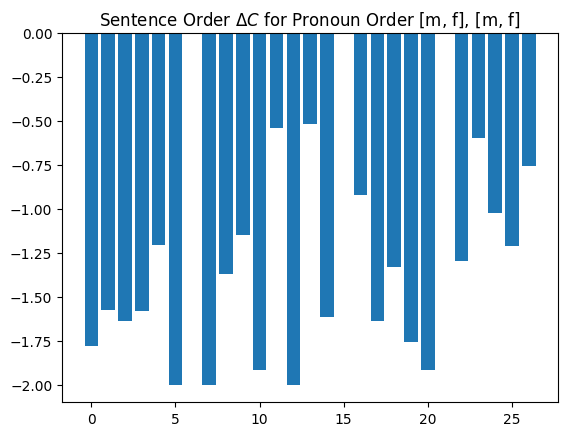

In [282]:
worked_indices = []
non_contextuality_fractions = []
broken_indices = []

for idx in range(60):
    try: 
        measurement_data = sentence_order_results(idx, data)
        frac = calculate_noncontextual_criterion(measurement_data)
        non_contextuality_fractions.append(frac)
        worked_indices.append(idx)
    except IndexError:
        broken_indices.append(idx)

plt.bar(worked_indices, non_contextuality_fractions)
plt.title(r'Sentence Order $\Delta C$ for Pronoun Order [m, f], [m, f]')
plt.savefig('../reports/figures/sentence_contextuality_mfmf.pdf')

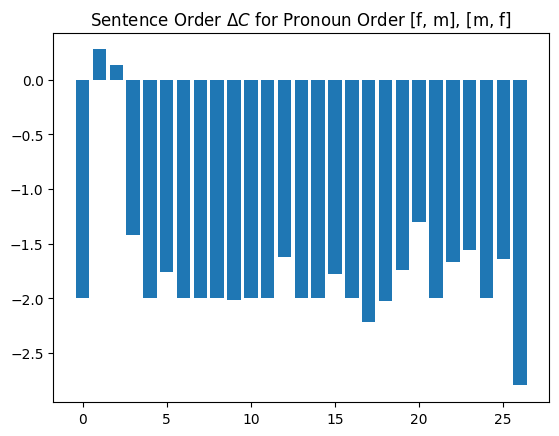

In [283]:
worked_indices = []
non_contextuality_fractions = []
broken_indices = []

for idx in range(60):
    try: 
        measurement_data = sentence_order_results(idx, data, pnoun_order=[1,0])
        frac = calculate_noncontextual_criterion(measurement_data)
        non_contextuality_fractions.append(frac)
        worked_indices.append(idx)
    except IndexError:
        broken_indices.append(idx)

plt.bar(worked_indices, non_contextuality_fractions)
plt.title(r'Sentence Order $\Delta C$ for Pronoun Order [f, m], [m, f]')
plt.savefig('../reports/figures/sentence_contextuality_fmmf.pdf')

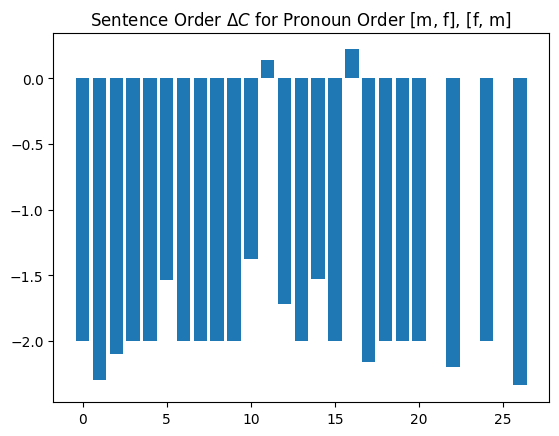

In [284]:
worked_indices = []
non_contextuality_fractions = []
broken_indices = []

for idx in range(60):
    try: 
        measurement_data = sentence_order_results(idx, data, pnoun_order=[0,1])
        frac = calculate_noncontextual_criterion(measurement_data)
        non_contextuality_fractions.append(frac)
        worked_indices.append(idx)
    except IndexError:
        broken_indices.append(idx)

plt.bar(worked_indices, non_contextuality_fractions)
plt.title(r'Sentence Order $\Delta C$ for Pronoun Order [m, f], [f, m]')
plt.savefig('../reports/figures/sentence_contextuality_mffm.pdf')

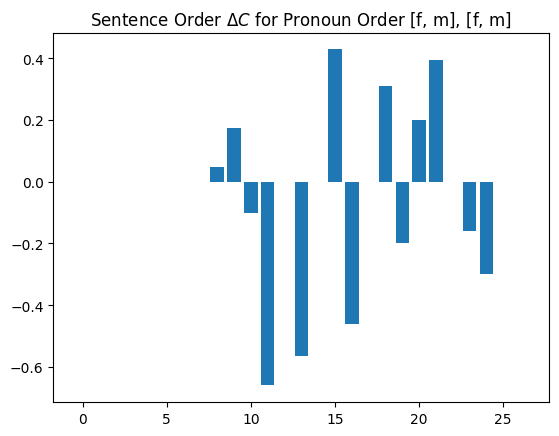

In [285]:
worked_indices = []
non_contextuality_fractions = []
broken_indices = []

for idx in range(60):
    try: 
        measurement_data = sentence_order_results(idx, data, pnoun_order=[1,1])
        frac = calculate_noncontextual_criterion(measurement_data)
        non_contextuality_fractions.append(frac)
        worked_indices.append(idx)
    except IndexError:
        broken_indices.append(idx)

plt.bar(worked_indices, non_contextuality_fractions)
plt.title(r'Sentence Order $\Delta C$ for Pronoun Order [f, m], [f, m]')
plt.savefig('../reports/figures/sentence_contextuality_fmfm.pdf')

## Testing with Qwen

In [286]:
QWEN_PATH = DATA_DIR / "measurements_Qwen1.5-0.5B-Chat_0.5.ndjson"

In [287]:
qwen_data = []
with open(QWEN_PATH, "r") as f:
    for line in f:
        if line.strip():  # avoid empty lines
            qwen_data.append(json.loads(line))

Text(0.5, 1.0, 'Sentence Order $\\Delta C$ for Pronoun Order [m, f], [m, f]')

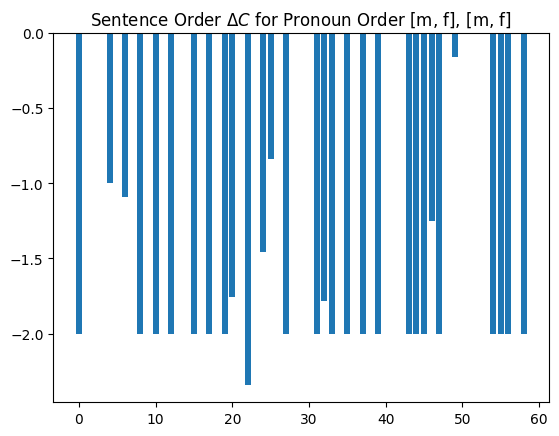

In [297]:
qwen_worked_indices = []
qwen_non_contextuality_fractions = []
qwen_broken_indices = []

for idx in range(60):
    try: 
        measurement_data = sentence_order_results(idx, qwen_data)
        frac = calculate_noncontextual_criterion(measurement_data)
        qwen_non_contextuality_fractions.append(frac)
        qwen_worked_indices.append(idx)
    except Exception as e:
        qwen_broken_indices.append((idx, e))

plt.bar(qwen_worked_indices, qwen_non_contextuality_fractions)
plt.title(r'Sentence Order $\Delta C$ for Pronoun Order [m, f], [m, f]')
#plt.savefig('../reports/figures/sentence_contextuality_mfmf.pdf')

Text(0.5, 1.0, 'Sentence Order $\\Delta C$ for Pronoun Order [m, f], [f, m]')

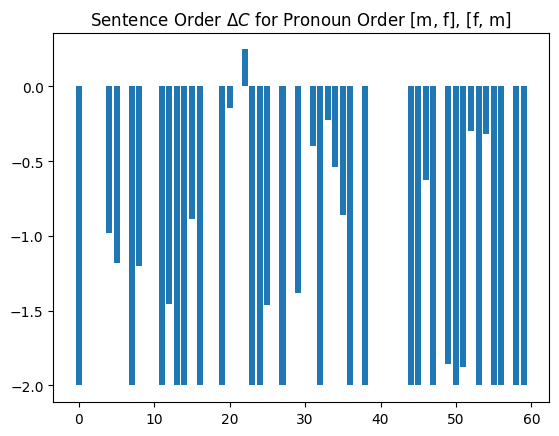

In [298]:
qwen_worked_indices = []
qwen_non_contextuality_fractions = []
qwen_broken_indices = []

for idx in range(60):
    try: 
        measurement_data = sentence_order_results(idx, qwen_data, pnoun_order=[0,1])
        frac = calculate_noncontextual_criterion(measurement_data)
        qwen_non_contextuality_fractions.append(frac)
        qwen_worked_indices.append(idx)
    except Exception as e:
        qwen_broken_indices.append((idx, e))

plt.bar(qwen_worked_indices, qwen_non_contextuality_fractions)
plt.title(r'Sentence Order $\Delta C$ for Pronoun Order [m, f], [f, m]')
#plt.savefig('../reports/figures/sentence_contextuality_mfmf.pdf')

Text(0.5, 1.0, 'Sentence Order $\\Delta C$ for Pronoun Order [f, m], [m, f]')

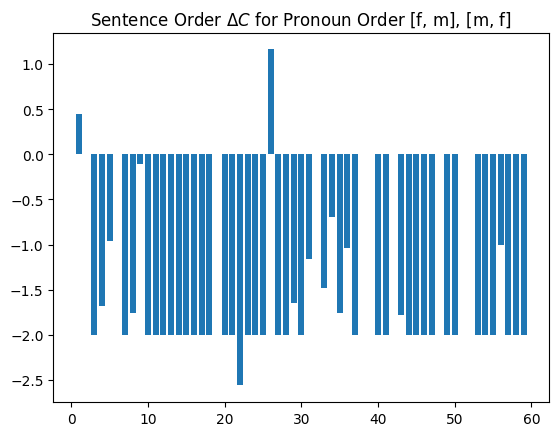

In [299]:
qwen_worked_indices = []
qwen_non_contextuality_fractions = []
qwen_broken_indices = []

for idx in range(60):
    try: 
        measurement_data = sentence_order_results(idx, qwen_data, pnoun_order=[1,0])
        frac = calculate_noncontextual_criterion(measurement_data)
        qwen_non_contextuality_fractions.append(frac)
        qwen_worked_indices.append(idx)
    except Exception as e:
        qwen_broken_indices.append((idx, e))

plt.bar(qwen_worked_indices, qwen_non_contextuality_fractions)
plt.title(r'Sentence Order $\Delta C$ for Pronoun Order [f, m], [m, f]')
#plt.savefig('../reports/figures/sentence_contextuality_mfmf.pdf')

Text(0.5, 1.0, 'Sentence Order $\\Delta C$ for Pronoun Order [f, m], [f, m]')

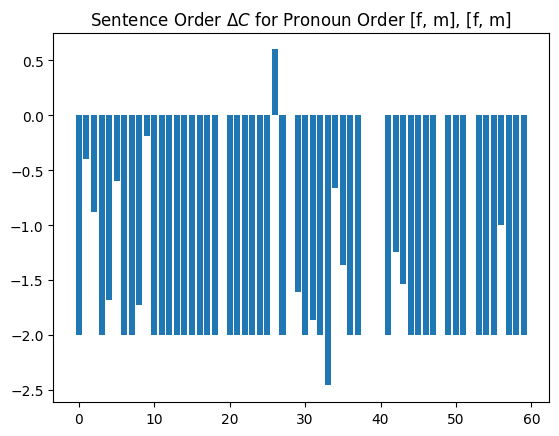

In [300]:
qwen_worked_indices = []
qwen_non_contextuality_fractions = []
qwen_broken_indices = []

for idx in range(60):
    try: 
        measurement_data = sentence_order_results(idx, qwen_data,pnoun_order=[1,1])
        frac = calculate_noncontextual_criterion(measurement_data)
        qwen_non_contextuality_fractions.append(frac)
        qwen_worked_indices.append(idx)
    except Exception as e:
        qwen_broken_indices.append((idx, e))

plt.bar(qwen_worked_indices, qwen_non_contextuality_fractions)
plt.title(r'Sentence Order $\Delta C$ for Pronoun Order [f, m], [f, m]')
#plt.savefig('../reports/figures/sentence_contextuality_mfmf.pdf')

## CbD Approach approach to 4-var system

In [305]:
def s1_4cycle(w,x,y,z):
    term1 = abs(w+x+y-z)
    term2 = abs(w+x-y-z)
    term3 = abs(w-x+y+z)
    term4 = abs(-w+x+y+z)
    return max(term1,term2,term3,term4)

In [345]:
cbd_expectation(0.321)

-0.358

In [346]:
cbd_correlation(.679, .308, .049)

-0.778

In [316]:
test_arr = np.array([[0.21, 0.79, 0.  , 0.  ],
                     [0.  , 1.  , 0.  , 0.  ],
                     [0.  , 0.  , 1.  , 0.  ],
                     [0.  , 0.  , 0.  , 1.  ]])

In [350]:
test_arr[0].reshape(2,2)

array([[0.21, 0.79],
       [0.  , 0.  ]])

In [349]:
np.sum(test_arr[0].reshape(2,2), axis=1)

array([1., 0.])

In [333]:
test_corrs = []
test_Vs = []
test_Ws = []
for row in test_arr.:
    # marginals
    px_test = row[2]+row[3]
    py_test = row[1]+row[3]

    V1 = cbd_expectation(px_test)
    W2 = cbd_expectation(py_test)
    V1W2 = cbd_correlation(px_test, py_test, row[3])

    test_corrs.append(V1W2)
    test_Vs.append(V1)
    test_Ws.append(W2)

s1_4cycle(*test_corrs)
    

np.float64(3.58)

In [334]:
test_Vs, test_Ws

([np.float64(-1.0), np.float64(-1.0), np.float64(1.0), np.float64(1.0)],
 [np.float64(0.5800000000000001),
  np.float64(1.0),
  np.float64(-1.0),
  np.float64(1.0)])

In [338]:
test_Ws_rotated = [test_Ws[-1]] + test_Ws[:-1]
test_Ws_rotated

[np.float64(1.0),
 np.float64(0.5800000000000001),
 np.float64(1.0),
 np.float64(-1.0)]

In [339]:
ind_contributions = np.sum([abs(v-w) for v,w in zip(test_Vs, test_Ws_rotated)])

In [340]:
s1_4cycle(*test_corrs) - 2 - ind_contributions

np.float64(-4.0)

In [341]:
# Is this correct? If so, move it to the code

In [ ]:
# I dont think this is correct--its (0,0), (0,1), (1,0), (1,1)
# That means for V1, it should be row[2]+row[3] and for W2 it should be row[1]+row[3]... right?

In [351]:
pronoun_order_dict = {
    'mf': 0,
    'fm': 1
}

In [356]:
list(product(pronoun_order_dict.values(), repeat=2))

[(0, 0), (0, 1), (1, 0), (1, 1)]

In [358]:
[list(i) for i in product(pronoun_order_dict.values(), repeat=2)]

[[0, 0], [0, 1], [1, 0], [1, 1]]

In [359]:
list(product(pronoun_order_dict.keys(), repeat=2))

[('mf', 'mf'), ('mf', 'fm'), ('fm', 'mf'), ('fm', 'fm')]

In [360]:
[''.join(i) for i in list(product(pronoun_order_dict.keys(), repeat=2))]

['mfmf', 'mffm', 'fmmf', 'fmfm']

# Logit CBD

In [1]:
import winogender_contextuality as wc
from winogender_contextuality.modeling.ModelProbs import *
from winogender_contextuality.modeling.contextuality import *
from winogender_contextuality.modeling.prompting import *
from winogender_contextuality.utils import *
from winogender_contextuality.modeling.pipeline import * 
from itertools import chain

2025-08-20 13:45:31.423 | INFO     | winogender_contextuality.config:<module>:13 - PROJ_ROOT path is: /home/sagar/winogender_contextuality
2025-08-20 13:45:31.423 | INFO     | winogender_contextuality.config:<module>:17 - DATA_ROOT path is: /data_users1/sagar/winogender_contextuality


2025-08-20 13:45:35.918 | INFO     | winogender_contextuality.modeling.run_local:<module>:9 - torch available: True
2025-08-20 13:45:35.918 | INFO     | winogender_contextuality.modeling.run_local:<module>:10 - 12.6
2025-08-20 13:45:35.959 | INFO     | winogender_contextuality.modeling.run_local:<module>:12 - _CudaDeviceProperties(name='NVIDIA TITAN Xp', major=6, minor=1, total_memory=12188MB, multi_processor_count=30, uuid=69e3ceae-9a8c-607c-5cd7-cde99d6659aa, L2_cache_size=3MB)


In [2]:
HF_KEY = ""

In [3]:
mp = wc.modeling.ModelProbs.ModelProbs(mode='gpu', 
                                       model_name="meta-llama/Llama-3.2-1B-Instruct", 
                                       key=HF_KEY, 
                                       model_path=wc.config.MODELS_DIR)

In [4]:
mp.load_model()

2025-08-20 13:45:37.031 | INFO     | winogender_contextuality.modeling.run_local:load_model:33 - Connected with Huggingface
2025-08-20 13:45:37.031 | INFO     | winogender_contextuality.modeling.run_local:load_model:43 - Loading quantized model
2025-08-20 13:45:40.015 | INFO     | winogender_contextuality.modeling.run_local:load_model:50 - Model cached in /data_users1/sagar/winogender_contextuality/models/cache
2025-08-20 13:45:40.015 | INFO     | winogender_contextuality.modeling.ModelProbs:load_model:55 - Loaded model meta-llama/Llama-3.2-1B-Instruct to /data_users1/sagar/winogender_contextuality/models


In [5]:
pairs = pd.read_csv(wc.config.INTERIM_DATA_DIR / "wino_pairs.tsv", sep="\t")

In [14]:
test_fixed_sent = pairs.template_1[0].replace('BLANK', 'he')
test_free_sent = pairs.template_2[0]
test_pronouns = pairs.differences_2[0]

In [22]:
#### Need to add a logit prompting function
test_message = wc.modeling.prompting.no_game_seq_logit_prompt(option_set=test_pronouns,
                                                            free_sentence=test_free_sent,
                                                            fixed_sentence=None)
test_message

('Below you will find a passage in *bold* which contains precisely one instance of the term BLANK. Your task is to replace BLANK with one of the options provided. The task is designed to be unambiguous, so please provide only one token for the blank and do not reorder the data.',
 "Given this passage: *The technician told the customer that BLANK had completed the repair.*\nReplace BLANK with one of the options: ['he', 'she']. Respond only in the following format {'BLANK': '<text>'}",
 "{'BLANK':")

In [23]:
test_prompt = role_content_base(*test_message)
#test_prompt
test_logits = mp.get_raw_logits(prompt=test_prompt).to('cpu')

In [24]:
test_logits

tensor([ 1.1670,  5.8164, -4.7617,  ..., -0.0143, -0.0131, -0.0118],
       dtype=torch.float16)

In [25]:
test_pronouns_list = ast.literal_eval(test_pronouns)

In [26]:
for txt, tok in zip(test_pronouns_list, mp.get_token_ids(options=[" "+s for s in test_pronouns_list])):
    print(f"{txt}: {tok}")

he: [568]
she: [1364]


In [27]:
test_logits[568], test_logits[1364]

(tensor(14.2891, dtype=torch.float16), tensor(13.1172, dtype=torch.float16))

In [28]:
masked_softmax([568, 1364], test_logits)

tensor([0.7637, 0.2366], dtype=torch.float16)